# 🐱🐶 Cats vs Dogs — Image Classification
**A Deep Learning project using Convolutional Neural Networks (CNN)**

---
**Project by:** Dhandabani  
**Internship:** Hex Softwares  
**Domain:** Machine Learning  
**Tools:** TensorFlow, Keras, Matplotlib, NumPy

## 1. Import Libraries

In [5]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import os

print('TensorFlow version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load Dataset

In [6]:
(train_data, val_data, test_data), info = tfds.load(
    'cats_vs_dogs',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    as_supervised=True,
    with_info=True
)

class_names = ['Cat', 'Dog']

print('Dataset loaded successfully!')
print(f'Training samples  : {sum(1 for _ in train_data)}')
print(f'Validation samples: {sum(1 for _ in val_data)}')
print(f'Test samples      : {sum(1 for _ in test_data)}')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.P9QXGL_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Dataset loaded successfully!
Training samples  : 16283
Validation samples: 3490
Test samples      : 3489


## 3. Visualize Sample Images

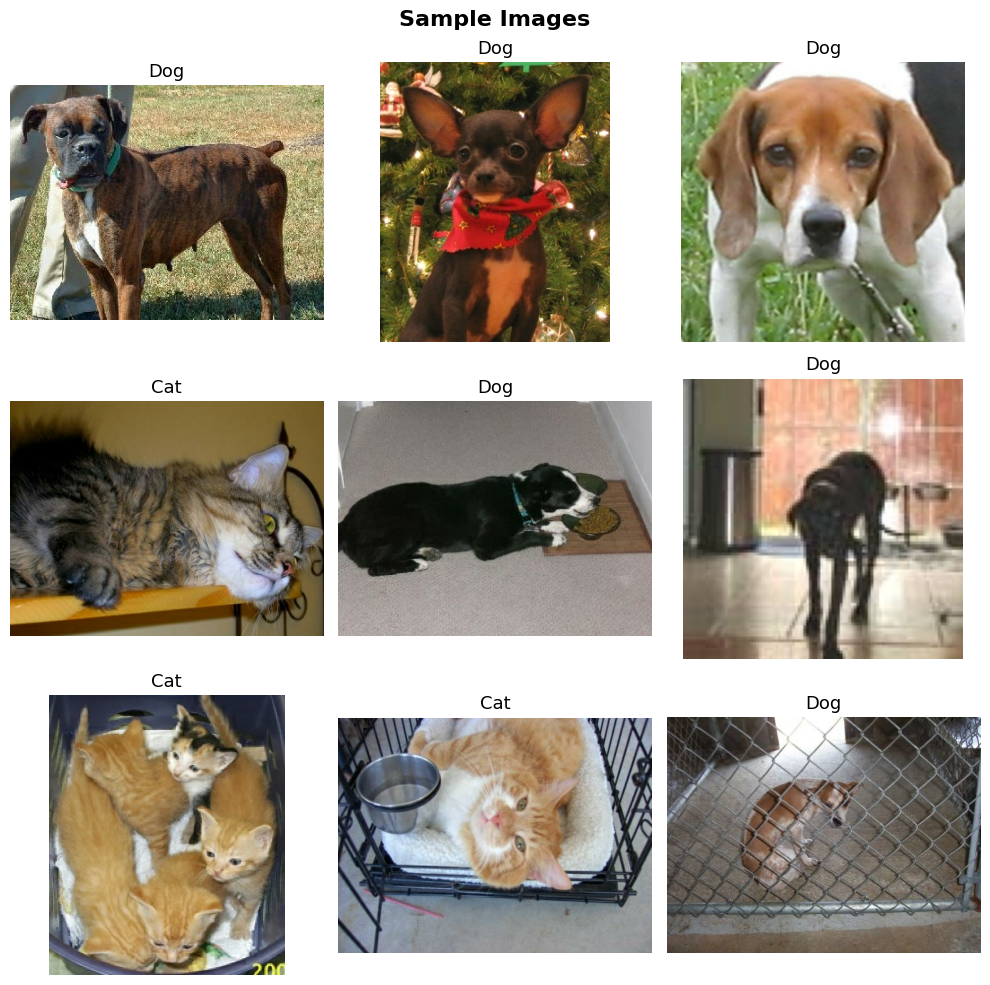

In [7]:
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(train_data.take(9)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_names[label], fontsize=13)
    plt.axis('off')
plt.suptitle('Sample Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Preprocess & Augment Data

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    return image, label

train_ds = train_data.map(preprocess).map(augment).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds   = val_data.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = test_data.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print('Data preprocessing complete!')

Data preprocessing complete!


## 5. Build CNN Model

In [9]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Fully Connected
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,825 (84.86 MB)

 Trainable params: 22,245,377 (84.86 MB)

 Non-trainable params: 448 (1.75 KB)

## 6. Train the Model

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.h5', save_best_only=True, verbose=1)
]

history = model.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.5846 - loss: 6.3721
Epoch 1: val_loss improved from None to 0.63510, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
509/509 ━━━━━━━━━━━━━━━━━━━━ 59s 96ms/step - accuracy: 0.6120 - loss: 2.5977 - val_accuracy: 0.6616 - val_loss: 0.6351
Epoch 2/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6827 - loss: 0.6235
Epoch 2: val_loss did not improve from 0.63510
509/509 ━━━━━━━━━━━━━━━━━━━━ 40s 78ms/step - accuracy: 0.6771 - loss: 0.6180 - val_accuracy: 0.6057 - val_loss: 1.5715
Epoch 3/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7127 - loss: 0.5541
Epoch 3: val_loss improved from 0.63510 to 0.54487, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
509/509 ━━━━━━━━━━━━━━━━━━━━ 40s 78ms/step - accuracy: 0.7176 - loss: 0.5443 - val_accuracy: 0.7393 - val_loss: 0.5449
Epoch 4/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7151 - loss: 0.6090
Epoch 4: val_loss improved from 0.54487 to 0.50510, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
509/509 ━━━━━━━━━━━━━━━━━━━━ 40s 78ms/step - accuracy: 0.7125 - loss: 0.5846 - val_accuracy: 0.7519 - val_loss: 0.5051
Epoch 5/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7445 - loss: 0.5196
Epoch 5: val_loss did not improve from 0.50510
509/509 ━━━━━━━━━━━━━━━━━━━━ 44s 87ms/step - accuracy: 0.7512 - loss: 0.5100 - val_accuracy: 0.5519 - val_loss: 0.7212
Epoch 6/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7490 - loss: 0.4948
Epoch 6: val_loss did not improve from 0.50510
509/509 ━━━━━━━━━━━━━━━━━━━━ 39s 77ms/step - accuracy: 0.7642 - loss: 0.4808 - val_accuracy: 0.6782 - val_loss: 0.5996
Epoch 7/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7752 - loss: 0.4616
Epoch 7: val_loss improved from 0.50510 to 0.48232, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
509/509 ━━━━━━━━━━━━━━━━━━━━ 41s 80ms/step - accuracy: 0.7758 - loss: 0.4608 - val_accuracy: 0.7725 - val_loss: 0.4823
Epoch 8/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7882 - loss: 0.4533
Epoch 8: val_loss improved from 0.48232 to 0.47467, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
509/509 ━━━━━━━━━━━━━━━━━━━━ 82s 80ms/step - accuracy: 0.7861 - loss: 0.4568 - val_accuracy: 0.7851 - val_loss: 0.4747
Epoch 9/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7972 - loss: 0.4414
Epoch 9: val_loss did not improve from 0.47467
509/509 ━━━━━━━━━━━━━━━━━━━━ 44s 87ms/step - accuracy: 0.7994 - loss: 0.4302 - val_accuracy: 0.5751 - val_loss: 1.3060
Epoch 10/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8047 - loss: 0.4249
Epoch 10: val_loss improved from 0.47467 to 0.44499, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
509/509 ━━━━━━━━━━━━━━━━━━━━ 41s 80ms/step - accuracy: 0.8081 - loss: 0.4115 - val_accuracy: 0.8032 - val_loss: 0.4450
Epoch 11/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8218 - loss: 0.3801
Epoch 11: val_loss did not improve from 0.44499
509/509 ━━━━━━━━━━━━━━━━━━━━ 40s 78ms/step - accuracy: 0.8254 - loss: 0.3696 - val_accuracy: 0.8011 - val_loss: 0.4459
Epoch 12/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8361 - loss: 0.3597
Epoch 12: val_loss did not improve from 0.44499
509/509 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.8387 - loss: 0.3525 - val_accuracy: 0.7971 - val_loss: 0.5114
Epoch 13/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8498 - loss: 0.3366
Epoch 13: val_loss did not improve from 0.44499
509/509 ━━━━━━━━━━━━━━━━━━━━ 39s 77ms/step - accuracy: 0.8531 - loss: 0.3291 - val_accuracy: 0.8009 - val_loss: 0.5529
Epoch 13: early stopping
Restoring model weights from the end of t

## 7. Plot Training Results

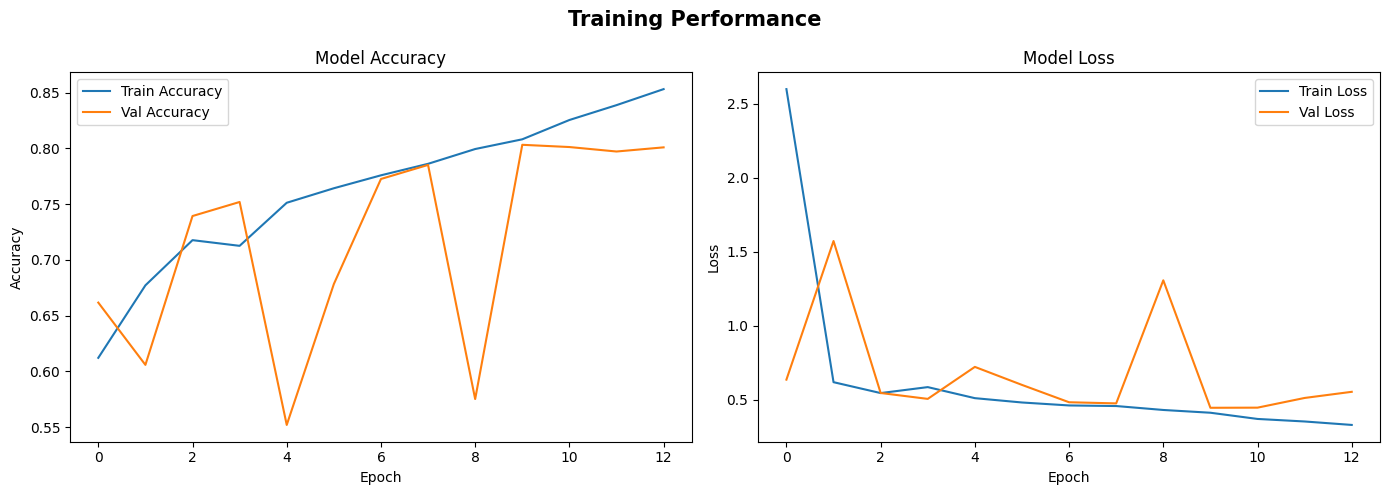

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.suptitle('Training Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Evaluate on Test Data

In [12]:
test_loss, test_acc = model.evaluate(test_ds)
print(f'\nTest Accuracy : {test_acc * 100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.8077 - loss: 0.4108

Test Accuracy : 80.77%
Test Loss     : 0.4108


## 9. Confusion Matrix

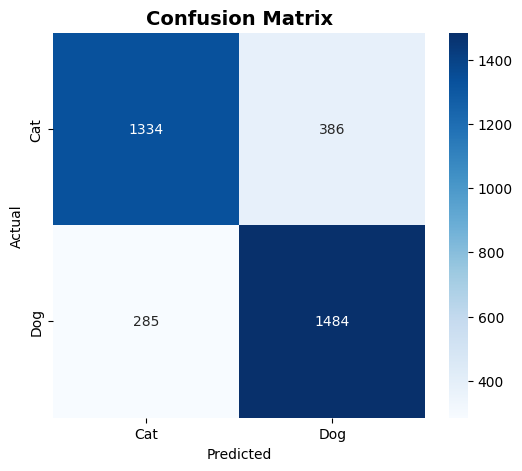


Classification Report:
              precision    recall  f1-score   support

         Cat       0.82      0.78      0.80      1720
         Dog       0.79      0.84      0.82      1769

    accuracy                           0.81      3489
   macro avg       0.81      0.81      0.81      3489
weighted avg       0.81      0.81      0.81      3489



In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true, y_pred = [], []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend((preds > 0.5).astype(int).flatten())
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

## 10. Predict on New Images

In [ ]:
plt.figure(figsize=(12, 8))

for i, (image, label) in enumerate(test_data.take(6)):
    img_resized = tf.image.resize(image, [IMG_SIZE, IMG_SIZE]) / 255.0
    pred = model.predict(np.expand_dims(img_resized, axis=0), verbose=0)[0][0]
    predicted = 'Dog' if pred > 0.5 else 'Cat'
    actual    = class_names[label.numpy()]
    confidence = pred if pred > 0.5 else 1 - pred

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    color = 'green' if predicted == actual else 'red'
    plt.title(f'Pred: {predicted} ({confidence*100:.1f}%)\nActual: {actual}',
              color=color, fontsize=10)
    plt.axis('off')

plt.suptitle('Prediction Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Save Final Model

In [ ]:
model.save('cats_vs_dogs_final.keras')
print('Model saved as cats_vs_dogs_final.h5')
print('Project Complete!')

In [ ]:
!pip install gradio

In [17]:
import gradio as gr
import numpy as np
from tensorflow.keras.models import load_model
import tensorflow as tf

# Load your trained model
model = load_model('cats_vs_dogs_final.keras')

def predict_image(img):
    img = tf.image.resize(img, [224, 224])
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)[0][0]

    confidence = float(prediction if prediction > 0.5 else 1 - prediction)
    label = "🐶 Dog" if prediction > 0.5 else "🐱 Cat"

    return {label: confidence, "Other": 1 - confidence}

# Launch Web App
app = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(),
    outputs=gr.Label(num_top_classes=2),
    title="🐱🐶 Cats vs Dogs Classifier",
    description="Upload any Cat or Dog image — AI will predict it!",
    theme="soft"
)

app.launch(share=True)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 18 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6359703f95cd12e97f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [18]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
import os

# Check what files are available
print("Files in /content/")
print(os.listdir('/content/'))

# Copy whichever model file exists
if os.path.exists('cats_vs_dogs_final.keras'):
    shutil.copy('cats_vs_dogs_final.keras',
                    '/content/drive/MyDrive/cats_vs_dogs_final.keras')
    print('Keras model saved to Drive!')

elif os.path.exists('cats_vs_dogs_final.h5'):
    shutil.copy('cats_vs_dogs_final.h5',
                    '/content/drive/MyDrive/cats_vs_dogs_final.h5')
    print('H5 model saved to Drive!')

else:
    print('Model file not found! Run Section 11 first!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in /content/
['.config', '.gradio', 'drive', 'best_model.h5', 'cats_vs_dogs_final.keras', 'sample_data']
Keras model saved to Drive!
